In [ ]:
#6. Object detection using Transfer Learning of CNN architectures 
a. Load in a pre-trained CNN model trained on a large dataset 
b. Freeze parameters (weights) in model’s lower convolutional layers 
c. Add custom classifier with several layers of trainable parameters to model 
d. Train classifier layers on training data available for task 
e. Fine-tune hyper parameters and unfreeze more layers as needed

In [ ]:
# a. Import necessary libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import matplotlib.pyplot as plt

In [ ]:
# b. Load / Generate Dataset

In [2]:
# (For demonstration, using random data. Replace this with your actual dataset.)

num_samples = 1000      # Number of samples
num_classes = 10        # Number of object classes

X_train = np.random.rand(num_samples, 224, 224, 3).astype(np.float32)
y_train = np.random.randint(0, num_classes, num_samples)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1000, 224, 224, 3)
y_train shape: (1000,)


In [ ]:
# c. Load pre-trained CNN model (Transfer Learning)

In [4]:
# Using MobileNetV2 pretrained on ImageNet as the base model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

9406464/9406464 [==============================] - 2s 0us/step


In [5]:
# Display the model architecture

base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[

In [ ]:
# d. Freeze lower convolutional layers

In [7]:
for layer in base_model.layers:
    layer.trainable = False

frozen_layers = [layer.name for layer in base_model.layers if not layer.trainable]
print("Number of frozen layers:", len(frozen_layers))

Number of frozen layers: 154


In [ ]:
# e. Add custom classifier (fully connected layers)

In [8]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [ ]:
# f. Compile the model

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
# Display complete model

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 2588490 (9.87 MB)
Trainable params: 1536586 (5.86 MB)
Non-trainable params: 1051904 (4.01 MB)
_________________________________________________________________


In [ ]:
# g. Train classifier layers

In [20]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
25/25 [==============================] - 28s 959ms/step - loss: 2.3481 - accuracy: 0.1125 - val_loss: 2.8968 - val_accuracy: 0.1450
Epoch 2/10
25/25 [==============================] - 18s 727ms/step - loss: 2.2937 - accuracy: 0.1125 - val_loss: 3.2943 - val_accuracy: 0.1450
Epoch 3/10
25/25 [==============================] - 18s 737ms/step - loss: 2.2295 - accuracy: 0.1800 - val_loss: 2.9088 - val_accuracy: 0.1450
Epoch 4/10
25/25 [==============================] - 18s 738ms/step - loss: 2.1127 - accuracy: 0.2375 - val_loss: 3.1850 - val_accuracy: 0.1450
Epoch 5/10
25/25 [==============================] - 18s 742ms/step - loss: 2.0250 - accuracy: 0.2550 - val_loss: 3.9600 - val_accuracy: 0.0700
Epoch 6/10
25/25 [==============================] - 21s 863ms/step - loss: 1.7978 - accuracy: 0.3713 - val_loss: 6.1654 - val_accuracy: 0.0950
Epoch 7/10
25/25 [==============================] - 19s 755ms/step - loss: 1.5908 - accuracy: 0.4338 - val_loss: 6.9441 - val_accuracy: 0.1150

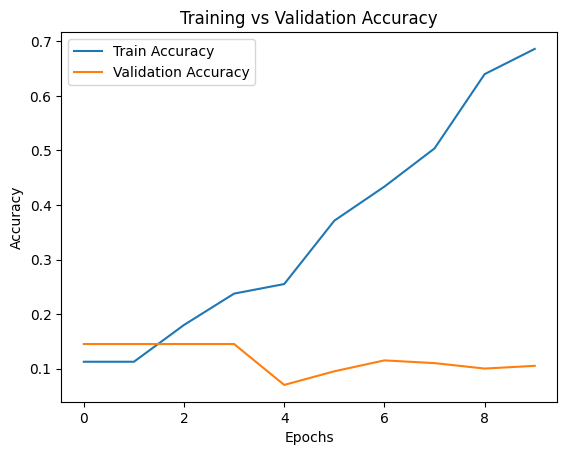

In [21]:
# Plot training history

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# h. Fine-tune model (Unfreeze last 20 layers)

In [22]:
for layer in base_model.layers[-20:]:layer.trainable = True

In [23]:
# Recompile with a smaller learning rate for fine-tuning

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
# Continue training (fine-tuning phase)

fine_tune_history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
25/25 [==============================] - 24s 821ms/step - loss: 0.5504 - accuracy: 0.8487 - val_loss: 16.3953 - val_accuracy: 0.1050
Epoch 2/5
25/25 [==============================] - 19s 751ms/step - loss: 0.4684 - accuracy: 0.8725 - val_loss: 15.9779 - val_accuracy: 0.0950
Epoch 3/5
25/25 [==============================] - 19s 752ms/step - loss: 0.4398 - accuracy: 0.8900 - val_loss: 15.5794 - val_accuracy: 0.1000
Epoch 4/5
25/25 [==============================] - 19s 778ms/step - loss: 0.3952 - accuracy: 0.9212 - val_loss: 15.1593 - val_accuracy: 0.1100
Epoch 5/5
25/25 [==============================] - 18s 741ms/step - loss: 0.3384 - accuracy: 0.9337 - val_loss: 14.7756 - val_accuracy: 0.1000


In [ ]:
ThankYou!!